In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lakhilkumar","key":"730d3af9b06bcfb96ba549fa66050881"}'}

In [3]:
import os
os.makedirs("/root/.kaggle", exist_ok=True)

# Find the uploaded file
for f in os.listdir("/content"):
    if "kaggle" in f.lower():
        os.rename(f"/content/{f}", "/root/.kaggle/kaggle.json")
        break

os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle API configured!")

Kaggle API configured!


In [4]:
!kaggle datasets list -s "microplastic segmentation"

ref                                            title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
---------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
muskanirfan29/microplastic-microscopy-dataset  Microplastic Microscopy Dataset                        1509370  2026-03-05 16:14:49.643000             41          6  0.8125           
asd1g1/microplastic-segmentation-dataset       microplastic-in-sewage-system-segmentation-dataset  2857259985  2025-12-31 19:34:11.737000             81          1  0.625            
sanghyeonaustinpark/mpset                      MP-Set                                              1953929277  2022-02-18 09:08:42.050000            566         15  0.6875           


In [5]:
!kaggle datasets download -d muskanirfan29/microplastic-microscopy-dataset
!unzip microplastic-microscopy-dataset.zip -d /content/dataset
print("Dataset downloaded!")

Dataset URL: https://www.kaggle.com/datasets/muskanirfan29/microplastic-microscopy-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.44M/1.44M [00:00<00:00, 151MB/s]

Archive:  microplastic-microscopy-dataset.zip
  inflating: /content/dataset/Experimentation Microscopy Samples/M1.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M10.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M11.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M12.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M2.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M3.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M4.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M5.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M6.jpeg  
  inflating: /content/dataset/Experimentation Microscopy Samples/M7.jpeg  
  inflating: /c

In [6]:
import os
for root, dirs, files in os.walk("/content/dataset"):
    for f in files:
        print(os.path.join(root, f))

/content/dataset/Experimentation Microscopy Samples/M12.jpeg
/content/dataset/Experimentation Microscopy Samples/M1.jpeg
/content/dataset/Experimentation Microscopy Samples/M9.jpeg
/content/dataset/Experimentation Microscopy Samples/M4.jpeg
/content/dataset/Experimentation Microscopy Samples/M3.jpeg
/content/dataset/Experimentation Microscopy Samples/M5.jpeg
/content/dataset/Experimentation Microscopy Samples/M2.jpeg
/content/dataset/Experimentation Microscopy Samples/M11.jpeg
/content/dataset/Experimentation Microscopy Samples/M8.jpeg
/content/dataset/Experimentation Microscopy Samples/M6.jpeg
/content/dataset/Experimentation Microscopy Samples/M7.jpeg
/content/dataset/Experimentation Microscopy Samples/M10.jpeg


In [7]:
!kaggle datasets download -d asd1g1/microplastic-segmentation-dataset
!unzip microplastic-segmentation-dataset.zip -d /content/dataset2
print("Done!")

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset2/0_train/01002.jpg  
  inflating: /content/dataset2/0_train/01006.jpg  
  inflating: /content/dataset2/0_train/01008.jpg  
  inflating: /content/dataset2/0_train/01009.jpg  
  inflating: /content/dataset2/0_train/01010.jpg  
  inflating: /content/dataset2/0_train/01011.jpg  
  inflating: /content/dataset2/0_train/01012.jpg  
  inflating: /content/dataset2/0_train/01013.jpg  
  inflating: /content/dataset2/0_train/01014.jpg  
  inflating: /content/dataset2/0_train/01015.jpg  
  inflating: /content/dataset2/0_train/01016.jpg  
  inflating: /content/dataset2/0_train/01017.jpg  
  inflating: /content/dataset2/0_train/01018.jpg  
  inflating: /content/dataset2/0_train/01019.jpg  
  inflating: /content/dataset2/0_train/01020.jpg  
  inflating: /content/dataset2/0_train/01022.jpg  
  inflating: /content/dataset2/0_train/01026.jpg  
  inflating: /content/dataset2/0_train/01027.jpg  
  inflating: /content/dataset2/

In [8]:
import os

train_imgs = len(os.listdir("/content/dataset2/0_train"))
train_masks = len(os.listdir("/content/dataset2/0_train_bi"))
val_imgs = len(os.listdir("/content/dataset2/1_valid"))
test_imgs = len(os.listdir("/content/dataset2/2_test"))

print(f"Train images: {train_imgs}")
print(f"Train masks: {train_masks}")
print(f"Validation images: {val_imgs}")
print(f"Test images: {test_imgs}")

Train images: 1531
Train masks: 1531
Validation images: 202
Test images: 202


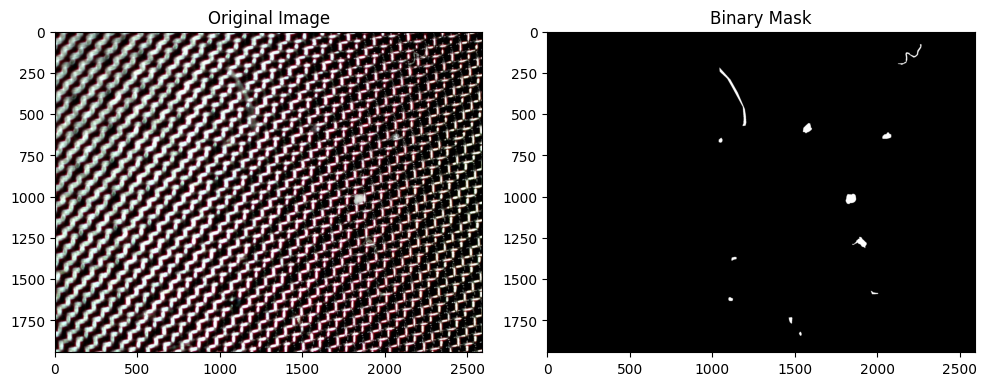

Image shape: (1944, 2592, 3)
Mask shape: (1944, 2592)


In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load one sample image and its mask
sample_img = cv2.imread("/content/dataset2/0_train/01002.jpg")
sample_mask = cv2.imread("/content/dataset2/0_train_bi/01002.jpg", cv2.IMREAD_GRAYSCALE)

# Display
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[1].imshow(sample_mask, cmap='gray')
axes[1].set_title("Binary Mask")
plt.tight_layout()
plt.show()

print(f"Image shape: {sample_img.shape}")
print(f"Mask shape: {sample_mask.shape}")

In [10]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import Sequence

IMG_SIZE = 128

class MicroplasticDataset(Sequence):
    def __init__(self, img_dir, mask_dir, batch_size=8):
        self.img_paths = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
        self.mask_paths = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
        self.batch_size = batch_size

    def __len__(self):
        return len(self.img_paths) // self.batch_size

    def __getitem__(self, idx):
        imgs, masks = [], []
        for i in range(idx * self.batch_size, (idx + 1) * self.batch_size):
            img = cv2.imread(self.img_paths[i])
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = cv2.imread(self.mask_paths[i], cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
            mask = (mask > 0.5).astype(np.float32)
            imgs.append(img)
            masks.append(mask[..., np.newaxis])
        return np.array(imgs), np.array(masks)

train_gen = MicroplasticDataset("/content/dataset2/0_train", "/content/dataset2/0_train_bi")
val_gen = MicroplasticDataset("/content/dataset2/1_valid", "/content/dataset2/1_valid_bi")

print(f"Train batches: {len(train_gen)}")
print(f"Val batches: {len(val_gen)}")
print("Data pipeline ready!")

Train batches: 191
Val batches: 25
Data pipeline ready!


In [11]:
from tensorflow.keras import layers, Model

def unet(input_size=(128, 128, 3)):
    inputs = layers.Input(input_size)

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(64, 3, activation='relu', padding='same')(c3)

    # Decoder
    u4 = layers.UpSampling2D()(c3)
    u4 = layers.concatenate([u4, c2])
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(u4)
    c4 = layers.Conv2D(32, 3, activation='relu', padding='same')(c4)

    u5 = layers.UpSampling2D()(c4)
    u5 = layers.concatenate([u5, c1])
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(16, 3, activation='relu', padding='same')(c5)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    return Model(inputs, outputs)

model = unet()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (UpSampling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 96)               │            │ conv2d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 64, 64,    │     27,680 │ concatenate[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 64, 64,    │      9,248 │ conv2d_6[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 128,  │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 48)               │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      6,928 │ concatenate_1[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      2,320 │ conv2d_8[0][0]  

 Total params: 118,273 (462.00 KB)

 Trainable params: 118,273 (462.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)

print("Training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9856 - loss: 0.0769 - val_accuracy: 0.9941 - val_loss: 0.0452
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 283s 1s/step - accuracy: 0.9932 - loss: 0.0439 - val_accuracy: 0.9941 - val_loss: 0.0365
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9932 - loss: 0.0420 - val_accuracy: 0.9941 - val_loss: 0.0373
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9932 - loss: 0.0416 - val_accuracy: 0.9941 - val_loss: 0.0340
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.9932 - loss: 0.0387 - val_accuracy: 0.9941 - val_loss: 0.0339
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.9932 - loss: 0.0391 - val_accuracy: 0.9941 - val_loss: 0.0338
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.9932 - loss: 0.0378 - val_accuracy: 0.9941 - val_loss: 0.0371
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.9932 - loss: 0.0375 - val_accu

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 368ms/step


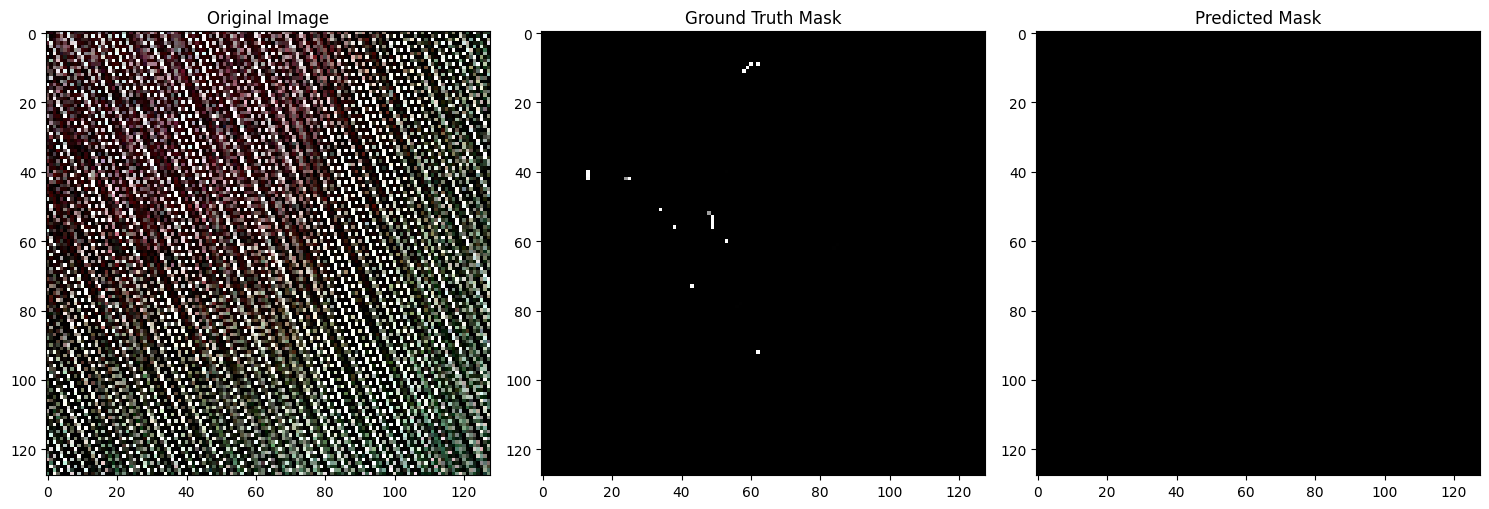

Prediction done!


In [13]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Load a test image and its mask
test_img_path = "/content/dataset2/2_test/00003.jpg"
test_mask_path = "/content/dataset2/2_test_bi/00003.jpg"

img = cv2.imread(test_img_path)
img_resized = cv2.resize(img, (128, 128)) / 255.0
mask = cv2.imread(test_mask_path, cv2.IMREAD_GRAYSCALE)
mask_resized = cv2.resize(mask, (128, 128)) / 255.0

# Predict
pred = model.predict(np.expand_dims(img_resized, axis=0))[0, :, :, 0]
pred_binary = (pred > 0.5).astype(np.uint8)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(cv2.resize(img, (128,128)), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Image")
axes[1].imshow(mask_resized, cmap='gray')
axes[1].set_title("Ground Truth Mask")
axes[2].imshow(pred_binary, cmap='gray')
axes[2].set_title("Predicted Mask")
plt.tight_layout()
plt.show()
print("Prediction done!")

In [14]:
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred):
    smooth = 1.
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def bce_dice_loss(y_true, y_pred):
    return 0.5 * K.binary_crossentropy(y_true, y_pred) + 0.5 * dice_loss(y_true, y_pred)

# Rebuild and retrain with better loss
model2 = unet()
model2.compile(optimizer='adam', loss=bce_dice_loss, metrics=['accuracy'])

history2 = model2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)
print("Retraining complete!")

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.9811 - loss: 0.5669 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 276s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 319s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 278s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accuracy: 0.9941 - val_loss: 0.5446
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 270s 1s/step - accuracy: 0.9932 - loss: 0.5512 - val_accu

In [15]:
import tensorflow.keras.backend as K
import numpy as np

# Check how many positive pixels exist in masks
sample_masks = []
import os
mask_dir = "/content/dataset2/0_train_bi"
for f in sorted(os.listdir(mask_dir))[:100]:
    m = cv2.imread(os.path.join(mask_dir, f), cv2.IMREAD_GRAYSCALE)
    sample_masks.append((m > 127).sum() / m.size)

pos_ratio = np.mean(sample_masks)
print(f"Average positive pixel ratio: {pos_ratio:.4f} ({pos_ratio*100:.2f}%)")
neg_ratio = 1 - pos_ratio
weight = neg_ratio / pos_ratio
print(f"Suggested pos_weight: {weight:.1f}")

Average positive pixel ratio: 0.0023 (0.23%)
Suggested pos_weight: 426.0


In [16]:
def weighted_bce_loss(y_true, y_pred):
    weight = 426.0
    bce = K.binary_crossentropy(y_true, y_pred)
    weighted = y_true * bce * weight + (1 - y_true) * bce
    return K.mean(weighted)

model3 = unet()
model3.compile(optimizer='adam', loss=weighted_bce_loss, metrics=['accuracy'])

history3 = model3.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    verbose=1
)
print("Training complete!")

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.0290 - loss: 2.2296 - val_accuracy: 0.0574 - val_loss: 1.9479
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.1047 - loss: 2.1241 - val_accuracy: 0.1606 - val_loss: 1.8847
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.1685 - loss: 2.0631 - val_accuracy: 0.2733 - val_loss: 1.8479
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.2066 - loss: 2.0551 - val_accuracy: 0.0678 - val_loss: 1.9783
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 280s 1s/step - accuracy: 0.2235 - loss: 1.9765 - val_accuracy: 0.3221 - val_loss: 1.7667
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 269s 1s/step - accuracy: 0.2956 - loss: 1.9161 - val_accuracy: 0.3141 - val_loss: 1.7282
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.3307 - loss: 1.8476 - val_accuracy: 0.3638 - val_loss: 1.6569
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.3602 - loss: 1.7936 - val_accu

Prediction stats:
Min: 0.0634
Max: 0.9606
Mean: 0.6740


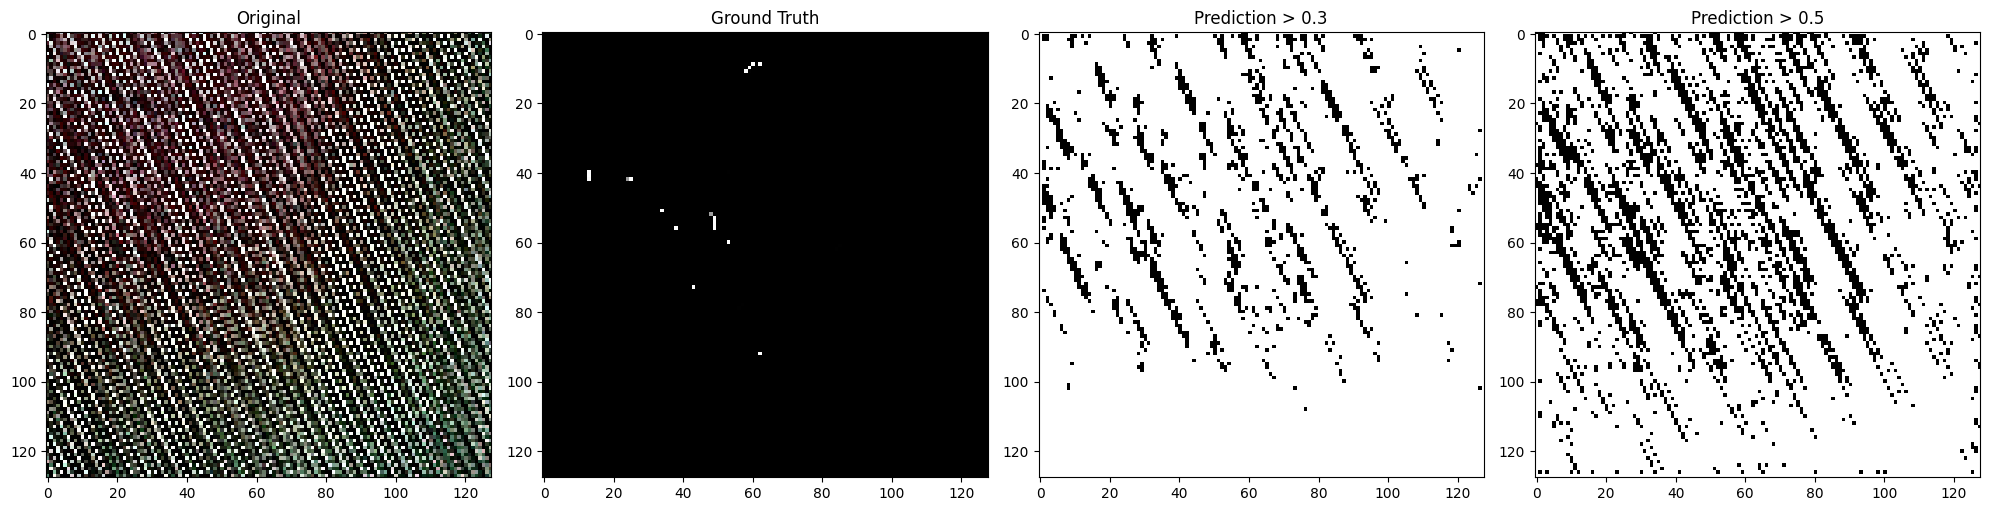

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

# Test image
test_img_path = "/content/dataset2/2_test/00003.jpg"
test_mask_path = "/content/dataset2/2_test_bi/00003.jpg"

img = cv2.imread(test_img_path)
mask = cv2.imread(test_mask_path, cv2.IMREAD_GRAYSCALE)

img_resized = cv2.resize(img, (128, 128)) / 255.0
mask_resized = cv2.resize(mask, (128, 128)) / 255.0

# IMPORTANT: use model3
pred = model3.predict(
    np.expand_dims(img_resized, axis=0),
    verbose=0
)[0, :, :, 0]

# Try lower thresholds
pred_03 = (pred > 0.3).astype(np.uint8)
pred_05 = (pred > 0.5).astype(np.uint8)

print("Prediction stats:")
print(f"Min: {pred.min():.4f}")
print(f"Max: {pred.max():.4f}")
print(f"Mean: {pred.mean():.4f}")

# Display
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(cv2.cvtColor(cv2.resize(img, (128,128)), cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")

axes[1].imshow(mask_resized, cmap='gray')
axes[1].set_title("Ground Truth")

axes[2].imshow(pred_03, cmap='gray')
axes[2].set_title("Prediction > 0.3")

axes[3].imshow(pred_05, cmap='gray')
axes[3].set_title("Prediction > 0.5")

plt.tight_layout()
plt.show()

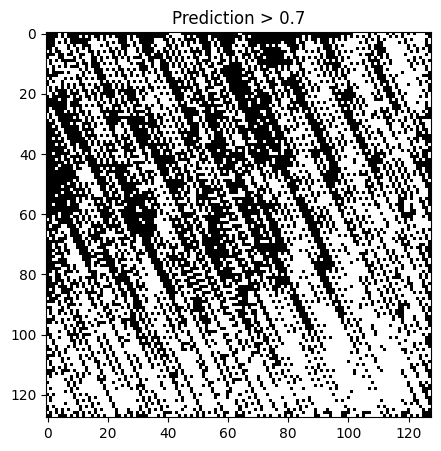

In [18]:
pred_07 = (pred > 0.7).astype(np.uint8)

plt.figure(figsize=(5,5))
plt.imshow(pred_07, cmap='gray')
plt.title("Prediction > 0.7")
plt.show()

In [19]:
model3.save("/content/microplastic_unet_model.h5")
print("Model saved successfully!")

Model saved successfully!


In [20]:
from google.colab import files
files.download("/content/microplastic_unet_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>